# BBB Dataset — EDA, Preprocessing, and Training (up to model fit)

This notebook builds a clean, well‑documented ML pipeline for the BBB dataset, including EDA (with plots), preprocessing, and model training (no evaluation yet).

## 🔍 Goals
- Load the dataset and confirm schema
- Perform EDA with key plots
- Build a clean preprocessing pipeline
- Train baseline models (Logistic Regression + SVM)

> We’ll stop after training; evaluation and SHAP come later.

In [1]:
# Imports (keep all needed imports here)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC



## 1) Load dataset and inspect schema

In [18]:
data_path = "BBB_dataset.tsv"

df = pd.read_csv(data_path, sep="\t", low_memory=False)

print("Shape:", df.shape)
print("Columns:", len(df.columns))

non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

display(df.head(2))

Shape: (7807, 1625)
Columns: 1625
Non-numeric columns: ['compound_name', 'IUPAC_name', 'SMILES', 'BBB+/BBB-', 'Inchi', 'reference', 'group', 'comments']


,NO.,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,...,10.171643,63.201012,398.068491,9.477821,2428,42,144,165,9.590278,6.097222
1,2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,...,10.893010,87.033695,520.101247,9.287522,4114,62,194,237,13.756944,7.916667


## 2) EDA — target distribution

BBB+/BBB-
BBB+    4956
BBB-    2851
Name: count, dtype: int64


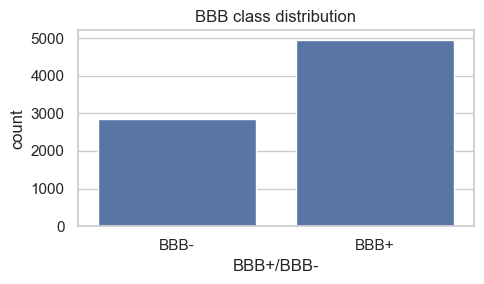

Imbalance ratio (BBB+ / BBB-): 1.74


In [19]:
target_col = "BBB+/BBB-"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found.")

# Count + plot class distribution
class_counts = df[target_col].value_counts(dropna=False)
print(class_counts)

plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df)
plt.title("BBB class distribution")
plt.tight_layout()
plt.show()

# Imbalance ratio
if "BBB+" in class_counts and "BBB-" in class_counts:
    ratio = class_counts["BBB+"] / class_counts["BBB-"]
    print(f"Imbalance ratio (BBB+ / BBB-): {ratio:.2f}")

**Interpretation & action:** If the classes are imbalanced (ratio far from 1), we’ll use `class_weight="balanced"` for classifiers like Logistic Regression and SVM.

Displaying Null values

In [20]:
pd.set_option("display.max_rows", None)
display(df.isnull().sum())

NO.                  0
compound_name     1109
IUPAC_name        1637
SMILES               0
CID               1637
logBB             6749
BBB+/BBB-            0
Inchi                0
threshold         4186
reference            0
group                0
comments          7789
ABC                  0
ABCGG                0
nAcid                0
nBase                0
SpAbs_A             10
SpMax_A             10
SpDiam_A            10
SpAD_A              10
SpMAD_A             10
LogEE_A             10
VE1_A               10
VE2_A               10
VE3_A               10
VR1_A               10
VR2_A               10
VR3_A               17
nAromAtom            0
nAromBond            0
nAtom                0
nHeavyAtom           0
nSpiro               0
nBridgehead          0
nHetero              0
nH                   0
nB                   0
nC                   0
nN                   0
nO                   0
nS                   0
nP                   0
nF                   0
nCl        

### Missingness buckets (0%, >50%, 100%)

In [47]:
missing_counts = df.isna().sum()
row_count = len(df)

fully_missing = missing_counts[missing_counts == row_count].index.tolist()
mostly_missing = missing_counts[missing_counts > 0.5 * row_count].index.tolist()
no_missing = missing_counts[missing_counts == 0].index.tolist()

print("Fully missing columns:", len(fully_missing))
print("Mostly missing (>50%) columns:", len(mostly_missing))
print("No-missing columns:", len(no_missing))

# Show a few examples
print("\nFully missing (sample):", fully_missing[:10])
print("Mostly missing (sample):", mostly_missing[:10])
print("No missing (sample):", no_missing[:10])

Fully missing columns: 76
Mostly missing (>50%) columns: 153
No-missing columns: 739

Fully missing (sample): ['MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXssssB', 'MAXsNH3', 'MAXssNH2', 'MAXsssNH', 'MAXssSiH2', 'MAXsssSiH']
Mostly missing (sample): ['logBB', 'threshold', 'comments', 'MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXsssB', 'MAXssssB', 'MAXdCH2']
No missing (sample): ['NO.', 'SMILES', 'BBB+/BBB-', 'Inchi', 'reference', 'group', 'ABC', 'ABCGG', 'nAcid', 'nBase']


**Interpretation & action:** Many descriptors have missing values, so we’ll use median imputation and drop columns that are entirely missing.

## 5) EDA — correlation snapshot (top-variance features)

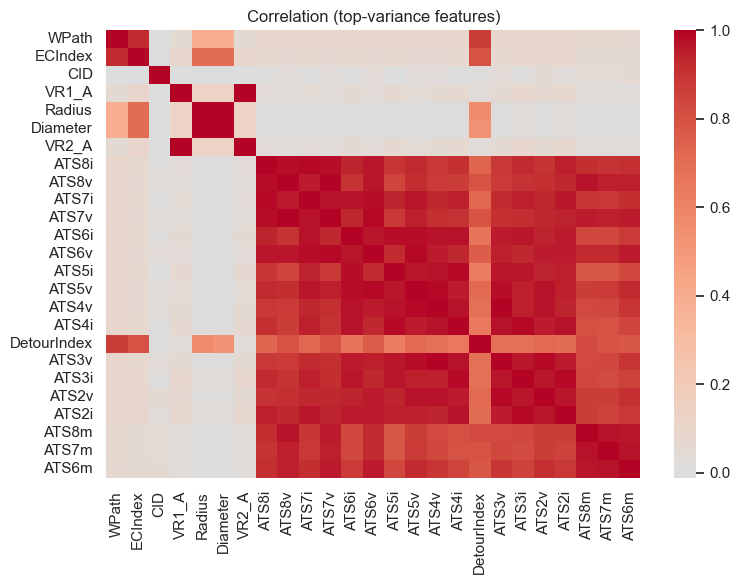

In [48]:
numeric_df = df.select_dtypes(include=["number"]).copy()

# Pick top-variance features to keep the heatmap readable
variances = numeric_df.var(numeric_only=True).sort_values(ascending=False)
top_features = variances.head(25).index

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[top_features].corr(), cmap="coolwarm", center=0)
plt.title("Correlation (top-variance features)")
plt.tight_layout()
plt.show()

### Full correlation table (top-variance features)

In [49]:
corr_table = numeric_df[top_features].corr()
display(corr_table)

,WPath,ECIndex,CID,VR1_A,Radius,Diameter,VR2_A,ATS8i,ATS8v,ATS7i,...,ATS4v,ATS4i,DetourIndex,ATS3v,ATS3i,ATS2v,ATS2i,ATS8m,ATS7m,ATS6m
WPath,1.000000,0.922296,-0.005906,0.051388,0.395120,0.395120,0.050210,0.089335,0.088588,0.089412,...,0.084631,0.090381,0.867955,0.089423,0.096548,0.094893,0.102237,0.076100,0.072162,0.067911
ECIndex,0.922296,1.000000,-0.007869,0.101876,0.698973,0.698973,0.100899,0.072466,0.071063,0.072108,...,0.069934,0.077235,0.802228,0.074744,0.082484,0.080525,0.089317,0.059792,0.055797,0.051741
CID,-0.005906,-0.007869,1.000000,-0.006556,-0.011400,-0.011399,-0.006914,0.012884,0.028423,0.012859,...,0.028799,0.004086,0.012945,0.034437,0.008825,0.048053,0.025569,0.040645,0.042397,0.056339
VR1_A,0.051388,0.101876,-0.006556,1.000000,0.128574,0.133557,0.999979,0.034735,0.027550,0.040263,...,0.054820,0.068644,0.030979,0.060029,0.080350,0.064043,0.074121,0.020404,0.020940,0.022788
Radius,0.395120,0.698973,-0.011400,0.128574,1.000000,1.000000,0.128157,0.010857,0.008852,0.009060,...,0.007263,0.014042,0.574641,0.008922,0.016938,0.013256,0.023412,0.004374,0.001531,-0.001429
Diameter,0.395120,0.698973,-0.011399,0.133557,1.000000,1.000000,0.133123,0.010858,0.008852,0.009060,...,0.007264,0.014043,0.536118,0.008923,0.016939,0.013257,0.023412,0.004374,0.001532,-0.001429
VR2_A,0.050210,0.100899,-0.006914,0.999979,0.128157,0.133123,1.000000,0.034169,0.026983,0.039677,...,0.054286,0.068105,0.030249,0.059479,0.079809,0.063469,0.073568,0.019864,0.020413,0.022244
ATS8i,0.089335,0.072466,0.012884,0.034735,0.010857,0.010858,0.034169,1.000000,0.976681,0.984679,...,0.888362,0.911538,0.729354,0.885768,0.926326,0.900080,0.948651,0.919732,0.900560,0.911753
ATS8v,0.088588,0.071063,0.028423,0.027550,0.008852,0.008852,0.026983,0.976681,1.000000,0.955655,...,0.874046,0.871879,0.801871,0.877720,0.897430,0.907144,0.929963,0.973952,0.945098,0.945843
ATS7i,0.089412,0.072108,0.012859,0.040263,0.009060,0.009060,0.039677,0.984679,0.955655,1.000000,...,0.933436,0.945042,0.722011,0.926831,0.950383,0.929789,0.964182,0.894518,0.885685,0.915123


**Actual Project**

## 11) SVM feature importance via permutation importance

Permutation importance is the best general-purpose approach for non-linear SVMs (like RBF):
- It works with any estimator.
- It measures the actual performance drop when each feature is shuffled.
- It avoids model-structure bias from tree-based split mechanics.


--FAILURE

**Trying L1 logistic regression method**

### Logistic Regression with L1 (feature selection)

L1 regularization shrinks many coefficients to exactly zero, so non-zero coefficients are the selected features to keep note of.

In [10]:
# L1 Logistic Regression = simple feature selection
# (Keeps only important features)

# 1) Load data
df = pd.read_csv("BBB_dataset.tsv", sep="\t", low_memory=False)

# 2) Target (BBB+/BBB-)
y = df["BBB+/BBB-"].map({"BBB+": 1, "BBB-": 0})

# 3) Drop non-feature / leakage columns
remove_cols = [
    "BBB+/BBB-", "NO.", "compound_name", "IUPAC_name", "SMILES",
    "CID", "Inchi", "reference", "comments", "group", "logBB"
]
X = df.drop(columns=[c for c in remove_cols if c in df.columns])

# 4) Handle missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7) L1 Logistic Regression
l1_model = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.1,
    max_iter=5000, class_weight="balanced"
)
l1_model.fit(X_train_scaled, y_train)

# 8) Evaluate
pred = l1_model.predict(X_test_scaled)
prob = l1_model.predict_proba(X_test_scaled)[:, 1]

print("=== L1 Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

# 9) Selected features (non-zero coefficients)
coef = pd.Series(l1_model.coef_[0], index=X.columns)
selected_features = coef[coef != 0]

print("\nTotal features:", X.shape[1])
print("Selected features:", len(selected_features))
print("\nTop 20 selected features:")
print(selected_features.abs().sort_values(ascending=False).head(20))

=== L1 Logistic Regression ===
Accuracy: 0.8597951344430218
F1 Score: 0.8888888888888888
ROC AUC: 0.9315833687040181

Total features: 1614
Selected features: 287

Top 20 selected features:
SssssN            0.456595
MDEC-33           0.436986
PEOE_VSA6         0.396077
EState_VSA5       0.376383
ATSC6are          0.372393
ETA_dEpsilon_D    0.317349
AATS4dv           0.304572
Lipinski          0.297314
JGI1              0.290175
nBase             0.286412
SaasC             0.277953
C3SP2             0.269482
GATS2p            0.268818
AATSC1i           0.262565
Kier3             0.257853
GATS6d            0.256428
MAXsOH            0.253005
PEOE_VSA9         0.241457
CIC1              0.237415
GATS7se           0.236798
dtype: float64


### SVM Linear on top 50 L1-selected features

Use the top 50 features ranked by L1 absolute coefficient, then train and evaluate an RBF SVM on that reduced feature set.

In [11]:
# Select top 50
top50_features = selected_features.abs().sort_values(ascending=False).head(50).index.tolist()

X_train_top50 = X_train[top50_features]
X_test_top50 = X_test[top50_features]

# SCALE AGAIN 
scaler_top50 = StandardScaler()
X_train_top50_scaled = scaler_top50.fit_transform(X_train_top50)
X_test_top50_scaled = scaler_top50.transform(X_test_top50)

# Train Linear SVM
svm_top50 = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True
)

svm_top50.fit(X_train_top50_scaled, y_train)

# Evaluate
pred = svm_top50.predict(X_test_top50_scaled)
prob = svm_top50.predict_proba(X_test_top50_scaled)[:, 1]
print("=== Linear SVM (Top 50 Features, Scaled) ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

=== Linear SVM (Top 50 Features, Scaled) ===
Accuracy: 0.853393085787452
F1 Score: 0.8849824208940231
ROC AUC: 0.9099851443123939


**SVM linear trained on Top 20 features**

In [12]:
# Select top 20
top20_features = selected_features.abs().sort_values(ascending=False).head(20).index.tolist()

X_train_top20 = X_train[top20_features]
X_test_top20 = X_test[top20_features]

# SCALE
scaler_top20 = StandardScaler()
X_train_top20_scaled = scaler_top20.fit_transform(X_train_top20)
X_test_top20_scaled = scaler_top20.transform(X_test_top20)

# Train Linear SVM
svm_top20 = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True
)

svm_top20.fit(X_train_top20_scaled, y_train)

# Evaluate
pred = svm_top20.predict(X_test_top20_scaled)
prob = svm_top20.predict_proba(X_test_top20_scaled)[:, 1]

print("=== Linear SVM (Top 20 Features, Scaled) ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

=== Linear SVM (Top 20 Features, Scaled) ===
Accuracy: 0.8124199743918054
F1 Score: 0.8519454269833249
ROC AUC: 0.8638246321448783


**Compress top 20 into 8 based on PCA**

### PCA compression: top 20 features → 8 components

Take the top 20 L1-ranked features, reduce them to 8 principal components, and train a linear SVM on the compressed representation.

In [13]:
# PCA compression: top 20 features → 8 components
# Then train a simple linear SVM

# Use precomputed L1-selected features
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# PCA (20 → 8)
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# Linear SVM
model = SVC(kernel="linear", C=1, class_weight="balanced", probability=True)
model.fit(X_train_pca, y_train)

# Evaluate
y_pred = model.predict(X_test_pca)
y_prob = model.predict_proba(X_test_pca)[:, 1]

print("\n=== Linear SVM (PCA 20 → 8) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nNumber of support vectors:", len(model.support_))
print("Sample predictions:", y_pred[:10])

Using precomputed L1-selected features...
Top 20 features: ['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'JGI1', 'nBase', 'SaasC', 'C3SP2', 'GATS2p', 'AATSC1i', 'Kier3', 'GATS6d', 'MAXsOH', 'PEOE_VSA9', 'CIC1', 'GATS7se']

Explained variance ratio: [0.18077506 0.12723815 0.09228454 0.07344943 0.0720691  0.05863505
 0.05727749 0.05097302]
Total variance explained: 0.7127018461081512

=== Linear SVM (PCA 20 → 8) ===
Accuracy: 0.8143405889884763
F1 Score: 0.8561507936507936
ROC AUC: 0.8475134408602151

Number of support vectors: 3342
Sample predictions: [0 1 0 1 0 1 0 1 0 1]


**QML with PCA with 4 features and 4 qubits**

In [29]:
# ==============================
# 1. Use precomputed L1 features
# ==============================
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Scale
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# 3. PCA (20 → 4)
# ==============================
pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# 4. Normalize for Quantum [0, π]  ✅ FIXED
# ==============================
def fit_minmax(X):
    return X.min(axis=0), X.max(axis=0)

def apply_minmax(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    
    # HARD CLIP (critical fix)
    X_scaled = np.clip(X_scaled, 0, np.pi)
    
    return X_scaled

# Fit ONLY on training data
X_min, X_max = fit_minmax(X_train_pca)

# Apply to both
X_train_pca = apply_minmax(X_train_pca, X_min, X_max)
X_test_pca  = apply_minmax(X_test_pca, X_min, X_max)

# ==============================
# 5. Reduce dataset size
# ==============================
X_train_q, _, y_train_q, _ = train_test_split(
    X_train_pca, y_train,
    train_size=60,
    random_state=42,
    stratify=y_train
)

X_test_q, _, y_test_q, _ = train_test_split(
    X_test_pca, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_q), "| Test size:", len(X_test_q))

# ==============================
# 6. Quantum Kernel + QSVC
# ==============================
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc_model = QSVC(quantum_kernel=quantum_kernel)
qsvc_model.fit(X_train_q, y_train_q)

# ==============================
# 7. Evaluation
# ==============================
y_pred = qsvc_model.predict(X_test_q)

print("\n=== Quantum SVM (PCA 20 → 4) ===")
print("Accuracy:", accuracy_score(y_test_q, y_pred))
print("F1 Score:", f1_score(y_test_q, y_pred))

try:
    y_score = qsvc_model.decision_function(X_test_q)
    print("ROC AUC:", roc_auc_score(y_test_q, y_score))
except Exception:
    print("ROC AUC not available")

Using precomputed L1-selected features...
Top 20 features: ['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'n4AHRing', 'JGI1', 'nBase', 'SaasC', 'GATS2p', 'C3SP2', 'Kier3', 'GATS6d', 'AATSC1i', 'MAXsOH', 'CIC1', 'PEOE_VSA9']

Explained variance ratio: [0.180878   0.13173649 0.09891918 0.07636303]
Total variance explained: 0.4878966979353276
Train size: 60 | Test size: 30

=== Quantum SVM (PCA 20 → 4) ===
Accuracy: 0.6666666666666666
F1 Score: 0.7619047619047619
ROC AUC: 0.5885167464114833


**QML,PCA with 8 components and 8 qubits**

In [32]:
# ==============================
# 1. Use precomputed L1 features
# ==============================
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Scale
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# 3. PCA (20 → 8)
# ==============================
pca = PCA(n_components=8)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# 4. Normalize for Quantum [0, π]  ✅ FIXED
# ==============================
def fit_minmax(X):
    return X.min(axis=0), X.max(axis=0)

def apply_minmax(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    
    # HARD CLIP → guarantees valid quantum angles
    X_scaled = np.clip(X_scaled, 0, np.pi)
    
    return X_scaled

# Fit ONLY on train
X_min, X_max = fit_minmax(X_train_pca)

# Apply to both
X_train_pca = apply_minmax(X_train_pca, X_min, X_max)
X_test_pca  = apply_minmax(X_test_pca, X_min, X_max)

# ==============================
# 5. Reduce dataset size
# ==============================
X_train_q, _, y_train_q, _ = train_test_split(
    X_train_pca, y_train,
    train_size=60,
    random_state=42,
    stratify=y_train
)

X_test_q, _, y_test_q, _ = train_test_split(
    X_test_pca, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_q), "| Test size:", len(X_test_q))

# ==============================
# 6. Quantum Kernel + QSVC
# ==============================
feature_map = ZZFeatureMap(
    feature_dimension=8,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc_model = QSVC(quantum_kernel=quantum_kernel)
qsvc_model.fit(X_train_q, y_train_q)

# ==============================
# 7. Evaluation
# ==============================
y_pred = qsvc_model.predict(X_test_q)

print("\n=== Quantum SVM (PCA 20 → 8) ===")
print("Accuracy:", accuracy_score(y_test_q, y_pred))
print("F1 Score:", f1_score(y_test_q, y_pred))

try:
    y_score = qsvc_model.decision_function(X_test_q)
    print("ROC AUC:", roc_auc_score(y_test_q, y_score))
except Exception:
    print("ROC AUC not available")

Using precomputed L1-selected features...
Top 20 features: ['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'n4AHRing', 'JGI1', 'nBase', 'SaasC', 'GATS2p', 'C3SP2', 'Kier3', 'GATS6d', 'AATSC1i', 'MAXsOH', 'CIC1', 'PEOE_VSA9']

Explained variance ratio: [0.180878   0.13173649 0.09891918 0.07636303 0.07206139 0.06593605
 0.05278539 0.05005059]
Total variance explained: 0.728730126363627
Train size: 60 | Test size: 30

=== Quantum SVM (PCA 20 → 8) ===
Accuracy: 0.7333333333333333
F1 Score: 0.8260869565217391
ROC AUC: 0.7416267942583732


**Saving our Circuit (for 4 qubit)**

Angle range check:
Min: 1.0971383338833387
Max: 2.1946819565382016

Quantum circuit diagram:


/opt/homebrew/Caskroom/miniconda/base/envs/qml_env/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


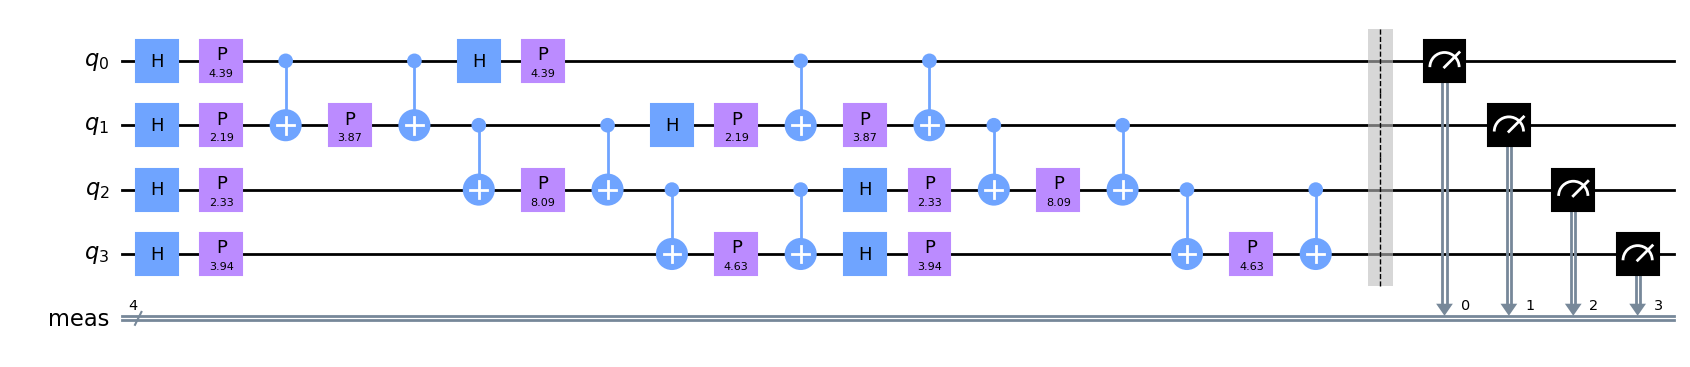


QASM saved to: qsvc_feature_map_4_qubits.qasm

QASM preview (first 15 lines):
OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg meas[4];
h q[0];
p(4.389363913076403) q[0];
h q[1];
p(2.1942766677666774) q[1];
cx q[0],q[1];
p(3.8718313299267515) q[1];
cx q[0],q[1];
h q[0];
p(4.389363913076403) q[0];
h q[2];
p(2.3284759827880404) q[2];


In [30]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit import qasm2
import numpy as np

# ==============================
# 1. MATCH QSVC PIPELINE
# ==============================
feature_dimension = 4

feature_map = ZZFeatureMap(
    feature_dimension=feature_dimension,
    reps=2,
    entanglement="linear"
)

# ==============================
# 2. Get REAL sample
# ==============================
top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

X_real = X_train[top_features]

# SAME preprocessing
X_real_scaled = scaler.transform(X_real)
X_real_pca = pca.transform(X_real_scaled)

# ==============================
# 3. SAFE QUANTUM SCALING
# ==============================
def apply_minmax_safe(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    
    # HARD CLIP (guaranteed bounds)
    X_scaled = np.clip(X_scaled, 0.0, np.pi)
    
    return X_scaled

# IMPORTANT: must be from SAME PCA(4) training
X_real_pca = apply_minmax_safe(X_real_pca, X_min, X_max)

real_sample = X_real_pca[0]

# ==============================
# 4. DEBUG VALIDATION (CRITICAL)
# ==============================
print("Angle range check:")
print("Min:", real_sample.min())
print("Max:", real_sample.max())

if real_sample.max() > np.pi + 1e-6:
    raise ValueError("❌ Angles exceed π — scaling mismatch!")
    
if real_sample.min() < -1e-6:
    raise ValueError("❌ Negative angles detected!")

# ==============================
# 5. Build circuit
# ==============================
circuit = feature_map.decompose().copy()

if circuit.num_clbits == 0:
    circuit.measure_all()

# ==============================
# 6. Bind parameters
# ==============================
params = sorted(circuit.parameters, key=lambda x: x.name)

if len(params) != len(real_sample):
    raise ValueError(
        f"Mismatch: {len(params)} params vs {len(real_sample)} features"
    )

bind_values = {
    param: float(real_sample[i])
    for i, param in enumerate(params)
}

circuit = circuit.assign_parameters(bind_values)

# ==============================
# 7. Draw circuit
# ==============================
print("\nQuantum circuit diagram:")
display(circuit.draw("mpl"))

# ==============================
# 8. Export QASM
# ==============================
qasm_text = qasm2.dumps(circuit)

qasm_path = "qsvc_feature_map_4_qubits.qasm"
with open(qasm_path, "w") as f:
    f.write(qasm_text)

print(f"\nQASM saved to: {qasm_path}")
print("\nQASM preview (first 15 lines):")
print("\n".join(qasm_text.splitlines()[:15]))

**Saving our circuit (8 qubits)**

In [31]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit import qasm2
import numpy as np

# ==============================
# 1. MATCH QSVC PIPELINE
# ==============================
feature_dimension = 8  # must match PCA(n_components=8)

feature_map = ZZFeatureMap(
    feature_dimension=feature_dimension,
    reps=2,
    entanglement="linear"
)

# ==============================
# 2. Get REAL sample (same pipeline)
# ==============================
top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

X_real = X_train[top_features]

# SAME preprocessing as training
X_real_scaled = scaler.transform(X_real)
X_real_pca = pca.transform(X_real_scaled)

# ==============================
# 3. APPLY SAME QUANTUM SCALING
# ==============================
def apply_minmax(X, X_min, X_max):
    return (X - X_min) / (X_max - X_min + 1e-9) * np.pi

# IMPORTANT: use SAME X_min, X_max from training (PCA-8 pipeline)
X_real_pca = apply_minmax(X_real_pca, X_min, X_max)

real_sample = X_real_pca[0]

# ==============================
# 4. Build circuit
# ==============================
circuit = feature_map.decompose().copy()

if circuit.num_clbits == 0:
    circuit.measure_all()

# ==============================
# 5. Bind parameters (safe order)
# ==============================
params = sorted(circuit.parameters, key=lambda x: x.name)

if len(params) != len(real_sample):
    raise ValueError(
        f"Mismatch: {len(params)} params vs {len(real_sample)} features"
    )

bind_values = {
    param: float(real_sample[i])
    for i, param in enumerate(params)
}

circuit = circuit.assign_parameters(bind_values)

# ==============================
# 6. Draw circuit
# ==============================
print("Quantum circuit diagram (8 qubits, with measurements):")
display(circuit.draw("mpl"))

# ==============================
# 7. Export QASM
# ==============================
qasm_text = qasm2.dumps(circuit)

qasm_path = "qsvc_feature_map_8_qubits.qasm"
with open(qasm_path, "w") as f:
    f.write(qasm_text)

print(f"QASM saved to: {qasm_path}")
print("\nQASM preview (first 15 lines):")
print("\n".join(qasm_text.splitlines()[:15]))

ValueError: Mismatch: 8 params vs 4 features

**Same classical ML for comparision**

In [33]:
# PCA compression: top 20 features → 8 components
# Then train a simple linear SVM

print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# Scale
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# PCA (20 → 8)
# ==============================
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# Reduce dataset (60 train / 30 test)
# ==============================
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_pca, y_train,
    train_size=60,
    random_state=42,
    stratify=y_train
)

X_test_small, _, y_test_small, _ = train_test_split(
    X_test_pca, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_small), "| Test size:", len(X_test_small))

# ==============================
# Linear SVM
# ==============================
model = SVC(kernel="linear", C=1, class_weight="balanced", probability=True)
model.fit(X_train_small, y_train_small)

# ==============================
# Evaluate
# ==============================
y_pred = model.predict(X_test_small)
y_prob = model.predict_proba(X_test_small)[:, 1]

print("\n=== Linear SVM (PCA 20 → 8, 60/30 split) ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred))
print("F1 Score:", f1_score(y_test_small, y_pred))
print("ROC AUC:", roc_auc_score(y_test_small, y_prob))



Using precomputed L1-selected features...
Top 20 features: ['SssssN', 'MDEC-33', 'PEOE_VSA6', 'EState_VSA5', 'ATSC6are', 'ETA_dEpsilon_D', 'AATS4dv', 'Lipinski', 'n4AHRing', 'JGI1', 'nBase', 'SaasC', 'GATS2p', 'C3SP2', 'Kier3', 'GATS6d', 'AATSC1i', 'MAXsOH', 'CIC1', 'PEOE_VSA9']

Explained variance ratio: [0.180878   0.13173649 0.09891918 0.07636303 0.07206139 0.06593605
 0.05278539 0.05005059]
Total variance explained: 0.728730126363627
Train size: 60 | Test size: 30

=== Linear SVM (PCA 20 → 8, 60/30 split) ===
Accuracy: 0.7666666666666667
F1 Score: 0.8372093023255814
ROC AUC: 0.7894736842105263


**ON IBM Hardware**

**API Key part**

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="ScNDOm2Sa0XBGJXdXFbWSLkQuD55Mcz7iAgcf-53RzCR",
    overwrite=True
)

**QSVC on a actual Quantum Computer**

In [22]:
# ==============================
# 0. Imports
# ==============================
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# 1. DATA PREPARATION
# ==============================
# Assume X, y already loaded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA → 4 features (matches qubits)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ==============================
# Quantum normalization [0, π]
# ==============================
def fit_minmax(X):
    return X.min(axis=0), X.max(axis=0)

def apply_minmax(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    return np.clip(X_scaled, 0, np.pi)

X_min, X_max = fit_minmax(X_train_pca)

X_train_q = apply_minmax(X_train_pca, X_min, X_max)
X_test_q  = apply_minmax(X_test_pca, X_min, X_max)

y_train_q = y_train.values if hasattr(y_train, "values") else y_train
y_test_q  = y_test.values if hasattr(y_test, "values") else y_test

# ==============================
# 2. CONNECT TO IBM BACKEND
# ==============================
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=4
)

print("Using backend:", backend)

sampler = Sampler(mode=backend)

# ==============================
# 3. FEATURE MAP
# ==============================
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement="linear"
)

# ==============================
# 4. BUILD KERNEL CIRCUIT
# ==============================
def build_kernel_circuit(x, x_prime):
    n = len(x)
    qc = QuantumCircuit(n, n)

    qc.compose(feature_map.assign_parameters(x), inplace=True)
    qc.compose(feature_map.assign_parameters(x_prime).inverse(), inplace=True)

    qc.measure(range(n), range(n))  # REQUIRED for Sampler V2

    return qc

# ==============================
# 5. OFFICIAL COUNTS EXTRACTION
# ==============================
def extract_prob_0000(result, n_qubits):
    pub_result = result[0]

    # Official method (works across backends)
    if hasattr(pub_result, "join_data"):
        counts = pub_result.join_data().get_counts()
    else:
        # fallback (rare cases)
        data = pub_result.data
        counts = None
        for attr in dir(data):
            obj = getattr(data, attr)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break

    if counts is None:
        raise ValueError("Counts extraction failed")

    total = sum(counts.values())
    zero_state = "0" * n_qubits

    return counts.get(zero_state, 0) / total

# ==============================
# 6. BUILD KERNEL MATRIX
# ==============================
def build_kernel_matrix(X1, X2, shots=1024):
    K = np.zeros((len(X1), len(X2)))

    for i in range(len(X1)):
        for j in range(len(X2)):
            print(f"Running pair ({i}, {j})")

            qc = build_kernel_circuit(X1[i], X2[j])
            qc_t = transpile(qc, backend)

            job = sampler.run([qc_t], shots=shots)
            result = job.result()

            prob_0000 = extract_prob_0000(result, qc.num_qubits)

            K[i, j] = prob_0000

            print(f"K[{i},{j}] = {K[i,j]:.4f}")

    return K

# ==============================
# 7. REDUCE DATASET (SAFE SIZE)
# ==============================
X_train_small = X_train_q[:4]
y_train_small = y_train_q[:4]

X_test_small = X_test_q[:2]
y_test_small = y_test_q[:2]

print("Train labels:", y_train_small)
print("Unique labels:", np.unique(y_train_small))

# ==============================
# 8. COMPUTE KERNEL MATRICES
# ==============================
print("\nBuilding TRAIN kernel...")
K_train = build_kernel_matrix(X_train_small, X_train_small)

print("\nBuilding TEST kernel...")
K_test = build_kernel_matrix(X_test_small, X_train_small)

print("\nK_train:\n", K_train)

# ==============================
# 9. TRAIN SVM
# ==============================
model = SVC(kernel="precomputed")
model.fit(K_train, y_train_small)

# ==============================
# 10. EVALUATE
# ==============================
y_pred = model.predict(K_test)

print("\n=== QSVC (IBM Hardware) ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred))
print("F1 Score:", f1_score(y_test_small, y_pred))

qiskit_runtime_service.__init__:WARNING:2026-04-01 08:54:04,843: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-01 08:54:05,743: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-01 08:54:10,674: Using instance: open-instance, plan: open
/var/folders/46/gk2t4snj69j52pxnsnxns7z80000gn/T/ipykernel_97209/1262851812.py:70: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Not

Using backend: <IBMBackend('ibm_fez')>
Train labels: [1 1 0 0]
Unique labels: [0 1]

Building TRAIN kernel...
Running pair (0, 0)
K[0,0] = 0.9033
Running pair (0, 1)
K[0,1] = 0.3018
Running pair (0, 2)
K[0,2] = 0.0986
Running pair (0, 3)
K[0,3] = 0.3232
Running pair (1, 0)
K[1,0] = 0.3076
Running pair (1, 1)
K[1,1] = 0.8945
Running pair (1, 2)
K[1,2] = 0.0195
Running pair (1, 3)
K[1,3] = 0.1885
Running pair (2, 0)
K[2,0] = 0.0898
Running pair (2, 1)
K[2,1] = 0.0371
Running pair (2, 2)
K[2,2] = 0.9141
Running pair (2, 3)
K[2,3] = 0.0166
Running pair (3, 0)
K[3,0] = 0.3164
Running pair (3, 1)
K[3,1] = 0.2041
Running pair (3, 2)
K[3,2] = 0.0195
Running pair (3, 3)
K[3,3] = 0.9053

Building TEST kernel...
Running pair (0, 0)
K[0,0] = 0.0176
Running pair (0, 1)
K[0,1] = 0.0215
Running pair (0, 2)
K[0,2] = 0.0234
Running pair (0, 3)
K[0,3] = 0.0361
Running pair (1, 0)
K[1,0] = 0.6797
Running pair (1, 1)
K[1,1] = 0.3643
Running pair (1, 2)
K[1,2] = 0.1436
Running pair (1, 3)
K[1,3] = 0.1699

